# SESSION 02: POINT OPERATIONS

- Ex2_1: Image Addition
- Ex2_2: Image Subtraction
- Ex2_3: Image Multiplication
- Ex2_4: Image Division
- Ex2_5: Noise Reduction using Image Averaging

In [1]:
# load packages
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# connect to GG Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Create a path link to Session folder
PATH = '/content/drive/MyDrive/IVP/Session_02/'

# Font size for figures
FS = 12

(177, 284, 3)
(1556, 2075, 3)


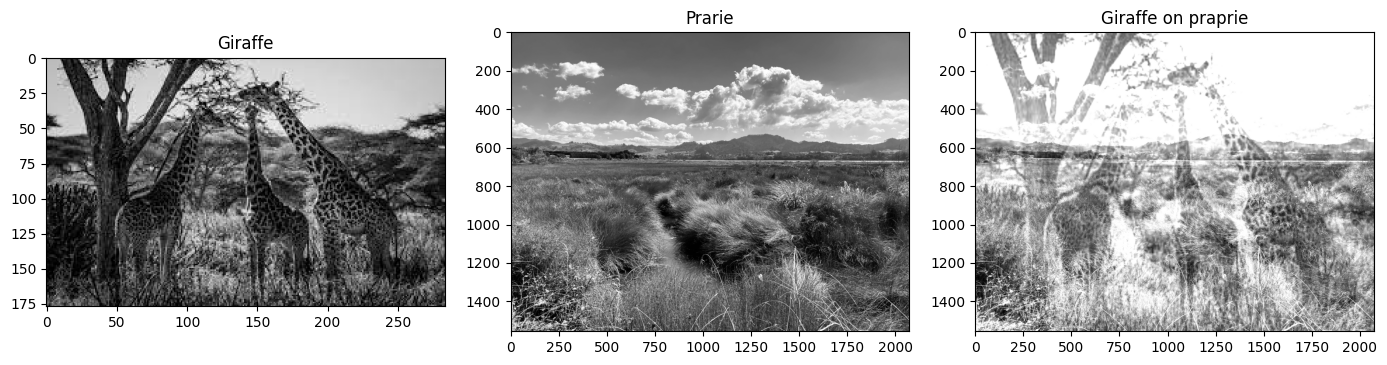

In [4]:
# Ex2_1: Image Addition

giraffe = cv2.imread(PATH + 'giraffe.jpg')
prarie = cv2.imread(PATH + 'prarie.jpg')

# Check dimensions of these two image
print(giraffe.shape)
print(prarie.shape)

# Convert from BGR to RGB
giraffe = cv2.cvtColor(giraffe, cv2.COLOR_BGR2RGB)
prarie = cv2.cvtColor(prarie, cv2.COLOR_BGR2RGB)

# Resive 'giraffe' image to the same size with 'prarie' image
## shape[1] = width (number of columns)
## shape[0] = height (number of rows)
giraffe_resized = cv2.resize(giraffe, (prarie.shape[1], prarie.shape[0]))

# Add two images
added_image = cv2.add(giraffe_resized, prarie)

# Display result
plt.figure(figsize=(14, 10))
plt.subplot(1, 3, 1), plt.imshow(giraffe), plt.title('Giraffe', fontsize=FS)
plt.subplot(1, 3, 2), plt.imshow(prarie), plt.title('Prarie', fontsize=FS)
plt.subplot(1, 3, 3), plt.imshow(added_image), plt.title('Giraffe on praprie', fontsize=FS)

plt.tight_layout()
plt.savefig(PATH + 'Ex2_1.png')
plt.show()


(470, 176, 3)
(470, 176, 3)


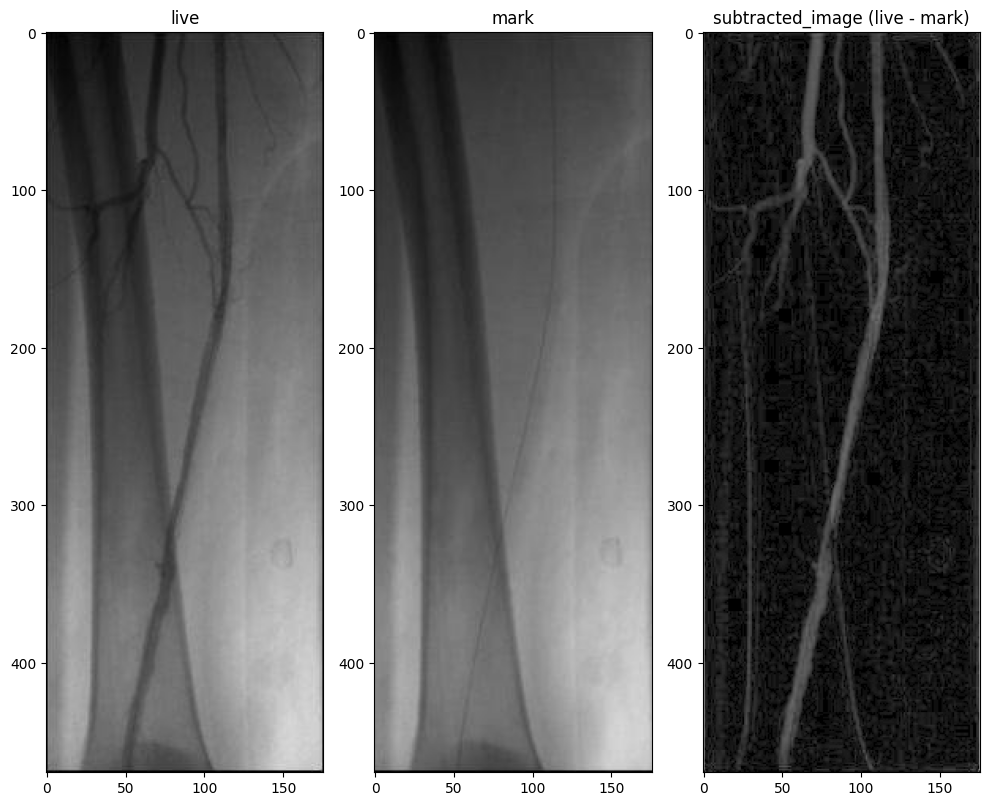

In [5]:
# Ex2_2: Image Substraction
live = cv2.imread(PATH + 'live.jpg', cv2.IMREAD_COLOR_RGB)
mark = cv2.imread(PATH + 'mask.jpg', cv2.IMREAD_COLOR_RGB)

print(live.shape)
print(mark.shape)

# Convert to float64 (0.0–1.0) to preserve precision during subtraction and power operations
# Convert from integer to double format (from 0->255 to 0.0000->1.0000)
live = live.astype(np.float64) / 255.0
mark = mark.astype(np.float64) / 255.0

# Substract two images
substracted_image = np.abs(live - mark) ** 0.5 # ** to for contrast enhancement

# Convert from double back to integer format to display
live = (live * 255).astype(np.uint8)
mark = (mark * 255).astype(np.uint8)
substracted_image = (substracted_image * 255).astype(np.uint8)

# Display results
plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1), plt.imshow(live), plt.title('live', fontsize=FS)
plt.subplot(1, 3, 2), plt.imshow(mark), plt.title('mark', fontsize=FS)
plt.subplot(1, 3, 3), plt.imshow(substracted_image), plt.title('subtracted_image (live - mark)', fontsize=FS)

plt.tight_layout()
plt.savefig(PATH + 'Ex2_2.png')
plt.show()

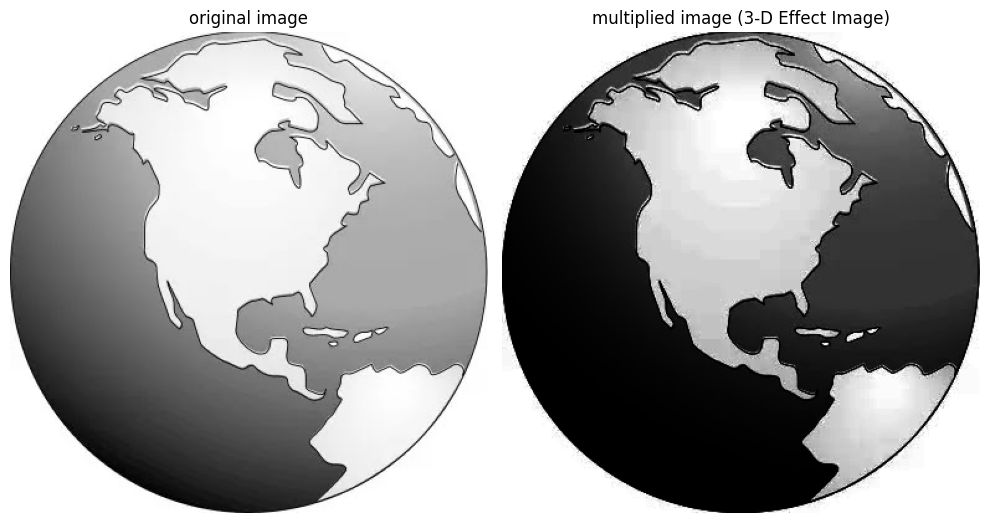

In [6]:
# Ex2_3: Image Multiplication

Img = cv2.imread(PATH + 'earth.jpg', cv2.IMREAD_COLOR_RGB)

# convert from integer to double format (from 0->255 to 0.0000->1.0000)
Img = Img.astype(np.float64) / 255.0

# Multiply the image with itself four times
multiplied_image = cv2.multiply(Img, cv2.multiply(Img, cv2.multiply(Img, Img)))

# Convert from double back to integer format to display
multiplied_image = (multiplied_image * 255).astype(np.uint8)

# Display result
plt.figure(figsize=(10, 10))
FS = 12 #fontsize caption
plt.subplot(1,2,1), plt.imshow(Img), plt.title('original image', fontsize=FS), plt.axis('off')
plt.subplot(1,2,2), plt.imshow(multiplied_image), plt.title('multiplied image (3-D Effect Image)', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex2_3.png', dpi=400)
plt.show()


(1125, 2000, 3)
(1125, 2000, 3)


/tmp/ipykernel_3090/241387820.py:15: RuntimeWarning: invalid value encountered in divide
  divided_image = np.divide(with_text, no_text)
/tmp/ipykernel_3090/241387820.py:21: RuntimeWarning: invalid value encountered in cast
  divided_image = (divided_image * 255).astype(np.uint8)


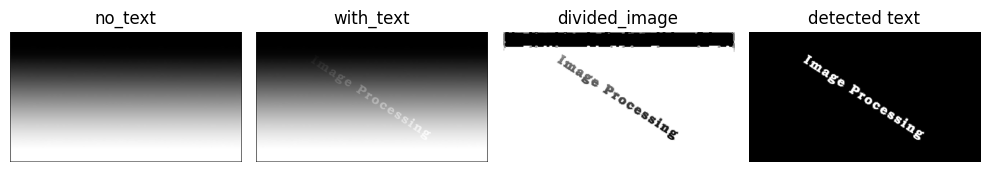

In [7]:
# Ex2_4: Image Division

no_text = cv2.imread(PATH + 'no_text.jpg', cv2.IMREAD_COLOR_RGB)
with_text = cv2.imread(PATH + 'with_text.jpg', cv2.IMREAD_COLOR_RGB)

# Check dimensions of the images
print(no_text.shape)
print(with_text.shape)

# Convert from integer to double format (from 0->255 to 0.0000->1.0000)
no_text = no_text.astype(np.float64) / 255.0
with_text = with_text.astype(np.float64) / 255.0

# Divide two images
divided_image = np.divide(with_text, no_text)
detected_text = (divided_image > 1.0001) # retains only pixel greater than 1.0001

# Convert from double back to integer format to display
no_text = (no_text * 255).astype(np.uint8)
with_text = (with_text * 255).astype(np.uint8)
divided_image = (divided_image * 255).astype(np.uint8)
detected_text = (detected_text * 255).astype(np.uint8)

# display result
plt.figure(figsize=(10, 10))
FS = 12

plt.subplot(1,4,1), plt.imshow(no_text), plt.title('no_text', fontsize=FS), plt.axis('off')
plt.subplot(1,4,2), plt.imshow(with_text), plt.title('with_text', fontsize=FS), plt.axis('off')
plt.subplot(1,4,3), plt.imshow(divided_image), plt.title('divided_image', fontsize=FS), plt.axis('off')
plt.subplot(1,4,4), plt.imshow(detected_text), plt.title('detected text', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex2_4.png', dpi=400)
plt.show()


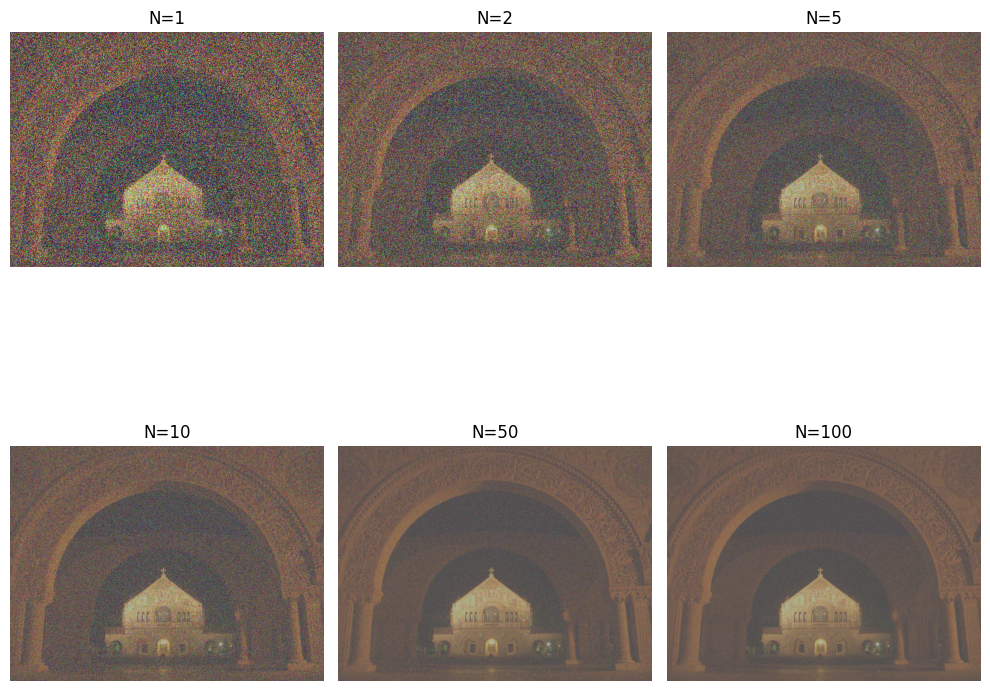

In [8]:
# Ex2_5: Noise Reduction using Image Averaging

Img = cv2.imread(PATH + 'quadnight.jfif', cv2.IMREAD_COLOR_RGB)

# Convert from integer to double format (from 0->255 to 0.0000->1.0000)
Img = Img.astype(np.float64) / 255.0

# Consider different number of images to calculate the everage
n_images = [1, 2, 5, 10, 50, 100]

plt.figure(figsize=(10, 10))

for i, N in enumerate(n_images):
  sum_Img = np.zeros_like(Img)

  # repeat N times, then accumulate to sum_Img
  for j in range(N):
    noise = np.random.normal(0, np.sqrt(0.98), Img.shape) # Gaussian noise
    noisy_Img = np.clip(Img + noise, 0, 1.0)              # Clip to valid range [0, 1]
    sum_Img += noisy_Img                                  # Accumumate noisy image

  # Calculate the averaging image => noise reducing as N increases
  avg_Img = sum_Img / N

  # Display results
  plt.subplot(2, 3, i+1), plt.imshow(avg_Img), plt.title(f'N={N}', fontsize=FS), plt.axis('off')

plt.tight_layout()
plt.savefig(PATH + 'Ex2_5.png', dpi=400)
plt.show()

